# Multiclass classification using FeedForward Neural Networks
Implementation with Pytorch, testing on the MNIST dataset.


Pyhton 3.12.0

miriamzara@MacBook-Pro-di-Miriam MCP % python3.12 -m pip install torch 

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# --- Data ---
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])  
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform) 
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=1000)

# --- Model ---
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # input:                28x28 = 786 neurons
        # first hidden layer:   256         neurons
        # output layer:         10          neurons
        self.fc1 = nn.Linear(28*28, 256)    # creates the trainable weights (256, 28*28) and bias (256) 
        self.fc2 = nn.Linear(256, 10)       # same, creates the trainable parameters of the layer

    def forward(self, x, return_intermediate=False):
        x1 = torch.relu(self.fc1(x))  # hidden layer output
        x2 = self.fc2(x1)             # final output
        if return_intermediate:
            return x2, x1
        return x2

model = Net()                               # instantiation of the network

# --- Training setup ---
criterion = nn.CrossEntropyLoss()           # definition of the loss function
optimizer = optim.Adam(model.parameters())  # definition of the otimizer
                                            # takes as argument all the parameters of the model
                                            # which are defined in the __init__() method of class Net()

# --- Train ---
for epoch in range(3):
    for x, y in train_loader:
        optimizer.zero_grad()               # initializes gradients to zero
        loss = criterion(model(x), y)       # compute loss, comparing the current output of
                                            # the model, model(x), and the real label, y.
        loss.backward()                     # loss is not just the vector of losses. It is
                                            # a tensor that tracks the entire computation graph
                                            # that produced it. 
                                            # so you can call directly .backward() on it.
                                            # this method crosses the graph from bottom to top
                                            # computing the gradients. These gradients
                                            # are stored as attributes in the parameter objects

        optimizer.step()                    # reads the gradients and performs the update
    print(f"Epoch {epoch+1} complete")

# --- Test ---
correct = 0
total = 0
model.eval()                                # switch to evaluation mode. for instance, 
                                            # deactivate dropout - if used in the first place. 
                                            # In this very simple network, it is useless. 

with torch.no_grad():                       # avoid the automatic tracking of gradients
                                            # this saves a lot of memory and time, since you do not need it.
                                            # without no_grad(), the call model(x) would automatically
                                            # produce the computational graph.
    for x, y in test_loader:
        logits = model(x)                   # outputs of the output layer
        pred = logits.argmax(1)             # takes the class with the maximum logit 
        correct += (pred == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

KeyboardInterrupt: 

Comments on the code:

1. torchvision.transforms contains routines for common image transformations, including cropping, padding, rotation, color to grayscale, brightness boosting and so on. Transformations can be chained together using transforms.Compose(). Custom transformations can also applied.
2. transforms.ToTensor() Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]. PIL (Pillow, previously Python Imaging Library) is a specific format for images. 
3. x.view() reshapes a tensor. Example: 

```{python}
x = torch.randn(3, 4, 2) # total = 24 elements
x.view(12, 2) # new shape: (12,2)
x.view(4, -1) # infers the second dimension automatically, new shape: (4, 6)
x.view(-1) # infers the first dimension automatically, new shape: (24,)
```
In this usage, x.view() takes as input the image, which is a 3d tensor (height, width, n channels) and flattens it to a 1D array.

4. DataLoader() provides an iterable over the dataset. The batch size parameter specifies how many samples should be loaded at once. Pytorch methods support batch processing. This mean that in the evaluating phase you can feed the whole test dataset at once to the network - if not too big - or in batches, in general. For the training phase, the batch size is used for stochastic gradient descent computation. Smaller batch -> noisier gradient descent steps, less computationally expensive. Larger batch -> less noise, more expensive, can get stuck in local minima. 

#### Export weights

#### option 1: binary file

In [8]:
"""
state_dict = model.state_dict()

for name, param in state_dict.items():
    # convert to numpy, ensure float32, flatten in row-major order (C order)
    arr = param.cpu().numpy().astype(np.float32).ravel(order='C')
    arr.tofile(f"{name}.bin")
    print(f"Saved {name}, shape {param.shape}")
"""

'\nstate_dict = model.state_dict()\n\nfor name, param in state_dict.items():\n    # convert to numpy, ensure float32, flatten in row-major order (C order)\n    arr = param.cpu().numpy().astype(np.float32).ravel(order=\'C\')\n    arr.tofile(f"{name}.bin")\n    print(f"Saved {name}, shape {param.shape}")\n'

#### option 2: text file 
The simplest, most transparent solution. However, it can get slow for big matrices, so if later in the project I want to scale up, I will need to change this.

In [4]:
state_dict = model.state_dict()

for name, param in state_dict.items():
    print(name, param.shape)

fc1.weight torch.Size([256, 784])
fc1.bias torch.Size([256])
fc2.weight torch.Size([10, 256])
fc2.bias torch.Size([10])


In [9]:
filenames = [f"{name}.txt" for name, _ in state_dict.items()]

for i, (name, param) in enumerate(state_dict.items()):
    if len(param.shape) == 2:
        # format for 2D tensors
        with open(filenames[i], "w") as f:
            # header contains the shape
            f.write(" ".join(map(str, list(param.shape))) + "\n")
            for row in param:
                row_string = " ".join(map(str, row.tolist()))   # map row to string, add " " separator
                f.write(row_string + "\n")                      # add newlines 

    if len(param.shape) == 1:
        # format for 1D tensors
        with open(filenames[i], "w") as f:
            f.write("1" + " " + str(param.shape[0]) + "\n")
            row_string = " ".join(map(str, param.tolist()))
            f.write(row_string)                      

#### Forward pass 
To later compare with the manually implemented c++ version

Label =  7


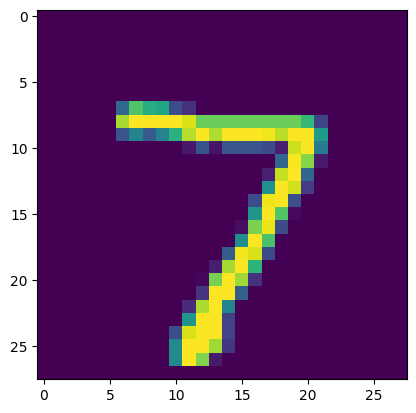

In [ ]:
import matplotlib.pyplot as plt


x, y = test_set[0]
plt.imshow(x.reshape(28,28))
print("Label = ", y)

In [ ]:
output, hidden = model(x, return_intermediate=True)

print("Output (logits): \n", output, "\n")

print("Output (before softmax) :\n", hidden[0], "\n")
print("Output of hidden layer:\n", hidden[1], "\n")

Output (logits): 
 tensor([[ -7.7957,  -9.2096,  -2.3412,  ...,  10.4983,  -4.6722,  -0.0878],
        [ -0.7863,  -7.0324,  -0.0796,  ..., -10.6210,  -4.3912,  -7.7948],
        [ -4.5872,   7.7970,  -0.9971,  ...,  -2.1745,  -0.4648,  -6.8812],
        ...,
        [ -9.5036, -10.5932,  -9.3903,  ...,  -0.4576,  -1.5921,   1.7142],
        [ -3.5817,  -8.1066,  -9.6932,  ...,  -7.6736,   1.9285,  -7.5161],
        [ -0.0775, -10.7614,  -1.3382,  ..., -11.9281,  -6.4486, -11.5281]],
       grad_fn=<AddmmBackward0>) 

Output (before softmax) :
 tensor([0.0000, 0.0000, 1.4357, 0.0000, 2.0486, 2.9194, 2.4563, 0.0000, 0.1400,
        0.6950, 0.0000, 0.9331, 0.0000, 0.0000, 0.0000, 0.0000, 0.7010, 0.0000,
        0.0000, 0.8005, 0.0000, 2.2430, 4.4108, 0.0000, 2.2525, 0.0000, 0.0000,
        0.0000, 0.1093, 0.0000, 0.0000, 0.0000, 0.9173, 0.0000, 0.0712, 1.8668,
        1.8503, 0.0000, 0.0000, 0.5329, 0.0000, 0.0000, 0.0000, 1.9482, 1.9643,
        0.9527, 0.0000, 0.4354, 0.5580, 1.4293, 0

In [4]:
matrix = np.random.rand(5,6)
name = "prova.txt"
with open(name, "w") as f:
    # header contains the shape
    f.write(" ".join(map(str, list(matrix.shape))) + "\n")
    for row in matrix:
        row_string = " ".join(map(str, row.tolist()))   # map row to string, add " " separator
        f.write(row_string + "\n")                      # add newlines 


```{python}

[num_layers] (int)
[sizes[0], sizes[1], ..., sizes[num_layers-1]] (ints)
Layer 0 weights (float array, row-major)
Layer 0 biases (float array)
Layer 1 weights ...
Layer 1 biases ...
...

```

In [2]:
import numpy as np

sizes = [784, 256, 10]
weights1 = np.loadtxt("neural_networks/fc1.weight.txt", dtype=np.float32, skiprows = 1)
biases1 = np.loadtxt("neural_networks/fc1.bias.txt", dtype=np.float32, skiprows = 1)
weights2 = np.loadtxt("neural_networks/fc2.weight.txt", dtype=np.float32, skiprows = 1)
biases2 = np.loadtxt("neural_networks/fc2.bias.txt", dtype=np.float32, skiprows = 1)

with open("nn.bin", "wb") as f:
    # wb= Writing in Binary mode
    np.array([len(sizes)], dtype=np.int32).tofile(f)   # num_layers
    np.array(sizes, dtype=np.int32).tofile(f)          # layer sizes
    weights1.tofile(f)
    biases1.tofile(f)
    weights2.tofile(f)
    biases2.tofile(f)